# DataJam Bogotá 2026  
## Señales del entorno  
**Violencia intrafamiliar, Consumos SPA y Lesiones personales**

**Equipo:** Jeisson Orlando Rodríguez · Erika Samboni · Luisa Fernanda Carbonell

Este notebook deja trazable el procesamiento que respalda el visor territorial. El objetivo es que cualquier persona pueda revisar cómo se consolidaron los datos, cómo se calcularon las tasas, cómo se construyeron los indicadores y qué pruebas estadísticas se usaron.

La visualización final está en HTML. Este archivo es el respaldo técnico: aquí queda la ruta del dato antes de llegar al tablero.


## 1. Alcance del análisis

El análisis trabaja a nivel de localidad para el periodo **2018-2025**.

La regla metodológica principal es simple: **las fuentes no se suman entre sí**. Violencia intrafamiliar, lesiones personales y consumo abusivo de SPA son fenómenos distintos. Se integran territorialmente para comparar señales, no para construir un conteo único.

**Qué se calcula aquí:**

- casos acumulados por localidad;
- tasas promedio anuales por cada 100.000 habitantes;
- persistencia de VIF en el periodo;
- Índice VIF;
- índice de contexto;
- brecha VIF-contexto;
- pruebas estadísticas exploratorias.

Las pruebas estadísticas se leen como asociación territorial. No prueban causalidad.


## 2. Librerías

Se usan librerías estándar de análisis de datos en Python. En Google Colab normalmente vienen instaladas. Si alguna falta, se puede instalar en la primera línea comentada.


In [1]:
# Si hace falta en Colab, descomentar:
# !pip install pandas numpy scipy matplotlib openpyxl

import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import spearmanr, kendalltau, pearsonr
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

ANIO_INICIO = 2018
ANIO_FIN = 2025
ANIOS_ANALISIS = ANIO_FIN - ANIO_INICIO + 1

TOTAL_VIF_ESPERADO = 283_773
N_LOCALIDADES_ESPERADAS = 20

print(f'Periodo de análisis: {ANIO_INICIO}-{ANIO_FIN} ({ANIOS_ANALISIS} años)')

Periodo de análisis: 2018-2025 (8 años)


## 3. Rutas de trabajo

El notebook intenta funcionar en tres entornos: Colab, computador local o el espacio de trabajo donde se generó el visor.  
Si el nombre del HTML cambia, solo hay que ajustar `HTML_CANDIDATOS`.


In [2]:
if Path('/content').exists():
    BASE_DIR = Path('/content')
elif Path('/mnt/data').exists():
    BASE_DIR = Path('/mnt/data')
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

HTML_CANDIDATOS = [
    BASE_DIR / 'reporte_graficos_propuesta_final_vif_2018_2025_RECOMENDACIONES_V3.html',
    BASE_DIR / 'reporte_graficos_propuesta_final_vif_2018_2025_RECOMENDACIONES_V2.html',
    BASE_DIR / 'index.html',
    BASE_DIR / 'index (1028).html',
]

BASE_INTEGRADA_CANDIDATOS = [
    OUTPUT_DIR / 'base_integrada_localidad_2018_2025.csv',
    BASE_DIR / 'base_integrada_localidad_2018_2025.csv',
]

print('BASE_DIR:', BASE_DIR)
print('OUTPUT_DIR:', OUTPUT_DIR)

BASE_DIR: /mnt/data
OUTPUT_DIR: /mnt/data/outputs


## 4. Funciones de apoyo

Estas funciones hacen tres tareas: encontrar archivos, extraer el arreglo `DATA` del HTML y revisar si el JSON embebido trae claves duplicadas. Esta validación es importante porque una versión anterior del visor tenía valores repetidos en el objeto de cada localidad.


In [3]:
def encontrar_archivo(candidatos):
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    return None


def extraer_data_desde_html(ruta_html):
    texto = Path(ruta_html).read_text(encoding='utf-8')
    patron = re.search(r'const\s+DATA\s*=\s*(\[.*?\]);', texto, flags=re.S)
    if patron is None:
        raise ValueError('No se encontró const DATA en el HTML.')
    data_raw = patron.group(1)
    data = json.loads(data_raw)
    return pd.DataFrame(data), data_raw


def separar_objetos_json(data_raw):
    objetos = []
    profundidad = 0
    inicio = None
    en_string = False
    escape = False

    for i, ch in enumerate(data_raw):
        if escape:
            escape = False
            continue
        if ch == '\\' and en_string:
            escape = True
            continue
        if ch == '"':
            en_string = not en_string
            continue
        if en_string:
            continue
        if ch == '{':
            if profundidad == 0:
                inicio = i
            profundidad += 1
        elif ch == '}':
            profundidad -= 1
            if profundidad == 0 and inicio is not None:
                objetos.append(data_raw[inicio:i+1])
                inicio = None
    return objetos


def contar_claves_duplicadas(data_raw):
    duplicados = []
    for idx, objeto in enumerate(separar_objetos_json(data_raw)):
        claves = re.findall(r'"([^"]+)"\s*:', objeto)
        conteo = Counter(claves)
        repetidas = {k: v for k, v in conteo.items() if v > 1}
        if repetidas:
            duplicados.append({'objeto': idx, 'duplicadas': repetidas})
    return duplicados


def minmax(serie):
    s = pd.to_numeric(serie, errors='coerce')
    if s.max() == s.min():
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100


def nivel_indice(x):
    if x >= 60:
        return 'alto'
    if x >= 35:
        return 'medio'
    return 'bajo'


def fuerza_correlacion(r):
    r = abs(r)
    if r >= 0.70:
        return 'alta'
    if r >= 0.40:
        return 'moderada'
    if r >= 0.20:
        return 'baja'
    return 'muy baja'


def interpretar_pvalor(p):
    if pd.isna(p):
        return 'sin cálculo'
    if p < 0.05:
        return 'asociación estadísticamente significativa al 5%'
    if p < 0.10:
        return 'asociación débil o marginal'
    return 'no se observa asociación estadísticamente significativa'

## 5. Carga de la base de trabajo

El camino ideal es leer las fuentes limpias desde `/data`. Para esta entrega se deja también una ruta de auditoría: si no están las fuentes originales, el notebook reconstruye la base desde el `DATA` embebido en el HTML final o desde el CSV integrado exportado.

Esto permite verificar que el visor y la base técnica hablan el mismo idioma.


In [4]:
ruta_html = encontrar_archivo(HTML_CANDIDATOS)
ruta_base_integrada = encontrar_archivo(BASE_INTEGRADA_CANDIDATOS)

if ruta_html:
    df, data_raw = extraer_data_desde_html(ruta_html)
    origen_datos = f'HTML: {ruta_html.name}'
    duplicados_json = contar_claves_duplicadas(data_raw)
elif ruta_base_integrada:
    df = pd.read_csv(ruta_base_integrada)
    data_raw = None
    origen_datos = f'CSV integrado: {ruta_base_integrada.name}'
    duplicados_json = []
else:
    raise FileNotFoundError('No se encontró HTML ni base integrada. Sube el visor o el CSV integrado al entorno de trabajo.')

print('Origen usado:', origen_datos)
print('Filas:', len(df))
print('Columnas:', len(df.columns))
df.head()

Origen usado: HTML: reporte_graficos_propuesta_final_vif_2018_2025_RECOMENDACIONES_V3.html
Filas: 20
Columnas: 25


,localidad,loc_norm,poblacion_ref,vif_casos_2018_2025,vif_tasa_prom_anual_100k,vif_persistencia_anios,pct_mujeres_nna_vif,lesiones_casos_2018_2025,lesiones_tasa_prom_anual_100k,spa_abusivo_casos_2018_2025,spa_abusivo_tasa_prom_anual_100k,indice_vif_familiar,indice_contexto,brecha_vif_contexto,rank_vif_carga,rank_vif_tasa,rank_vif_familiar,cambio_carga_vs_tasa,nivel_vif_familiar,nivel_contexto,tipo_decision,alerta_lectura,accion_sugerida,lectura_breve,lectura_breve_final
0,Bosa,BOSA,673077,31314.0,581.55,7,79.53,14132,262.45,5943,110.37,68.28,17.30,50.98,4,4,4,0,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 31.314 casos entre 2018 y 2025, con u...","Registra 31.314 casos entre 2018 y 2025, con u..."
1,Ciudad Bolívar,CIUDAD BOLIVAR,707569,32707.0,577.81,8,80.45,16160,285.48,4909,86.72,74.13,17.31,56.82,3,5,2,-2,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 32.707 casos entre 2018 y 2025, con u...","Registra 32.707 casos entre 2018 y 2025, con u..."
2,San Cristóbal,SAN CRISTOBAL,404697,17723.0,547.42,8,79.32,9979,308.22,2993,92.45,66.32,18.96,47.36,6,6,6,0,alto,bajo,VIF alta con contexto moderado,Baja: lectura territorial más estable.,La prioridad debería estar en rutas de atenció...,"Registra 17.723 casos entre 2018 y 2025, con u...","Registra 17.723 casos entre 2018 y 2025, con u..."
3,Los Mártires,LOS MARTIRES,99119,8819.0,1112.17,8,74.28,6496,819.22,7099,895.26,76.18,94.00,-17.82,12,1,1,11,alto,alto,VIF alta con entorno complejo,Media: posible efecto de población flotante o ...,Conviene revisar la oferta de atención familia...,"Registra 8.819 casos entre 2018 y 2025, con un...","Registra 8.819 casos entre 2018 y 2025, con un..."
4,Usme,USME,457302,15558.0,425.27,6,80.63,9623,263.04,3408,93.16,55.95,16.37,39.58,7,10,7,-3,medio,bajo,Seguimiento focalizado,Baja: lectura territorial más estable.,La VIF pesa más que las señales de contexto. V...,"Registra 15.558 casos entre 2018 y 2025, con u...","Registra 15.558 casos entre 2018 y 2025, con u..."


## 6. Estandarización mínima

Se convierten a número los campos que deben ser numéricos y se conserva una tabla por localidad. No se agregan nuevas fuentes en este paso; solo se ordena la base que alimenta el visor.


In [5]:
COLUMNAS_NUMERICAS = [
    'poblacion_ref',
    'vif_casos_2018_2025',
    'vif_tasa_prom_anual_100k',
    'vif_persistencia_anios',
    'pct_mujeres_nna_vif',
    'lesiones_casos_2018_2025',
    'lesiones_tasa_prom_anual_100k',
    'spa_abusivo_casos_2018_2025',
    'spa_abusivo_tasa_prom_anual_100k',
    'indice_vif_familiar',
    'indice_contexto',
    'brecha_vif_contexto'
]

for col in COLUMNAS_NUMERICAS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Se ordena por índice VIF para facilitar revisión.
df = df.sort_values('indice_vif_familiar', ascending=False).reset_index(drop=True)

df[['localidad', 'vif_casos_2018_2025', 'vif_tasa_prom_anual_100k', 'indice_vif_familiar', 'indice_contexto', 'brecha_vif_contexto']].head(10)

,localidad,vif_casos_2018_2025,vif_tasa_prom_anual_100k,indice_vif_familiar,indice_contexto,brecha_vif_contexto
0,Los Mártires,8819.0,1112.17,76.18,94.00,-17.82
1,Ciudad Bolívar,32707.0,577.81,74.13,17.31,56.82
2,La Candelaria,2128.0,1104.28,70.28,97.33,-27.05
3,Bosa,31314.0,581.55,68.28,17.30,50.98
4,Santa Fe,7813.0,887.45,68.21,69.66,-1.45
5,San Cristóbal,17723.0,547.42,66.32,18.96,47.36
6,Usme,15558.0,425.27,55.95,16.37,39.58
7,Kennedy,34615.0,397.53,46.76,14.46,32.30
8,Tunjuelito,7002.0,438.88,40.65,21.90,18.75
9,Rafael Uribe Uribe,12593.0,420.61,39.72,19.34,20.38


## 7. Validaciones básicas de calidad

Antes de calcular o interpretar, se revisa que la base tenga el tamaño esperado, que no existan duplicados de localidad, que la persistencia no supere los ocho años y que el total de VIF coincida con el visor.


In [6]:
validaciones = []

validaciones.append({
    'validacion': 'Número de localidades',
    'valor': df['localidad'].nunique(),
    'esperado': N_LOCALIDADES_ESPERADAS,
    'ok': df['localidad'].nunique() == N_LOCALIDADES_ESPERADAS
})

validaciones.append({
    'validacion': 'Filas por localidad',
    'valor': len(df),
    'esperado': N_LOCALIDADES_ESPERADAS,
    'ok': len(df) == N_LOCALIDADES_ESPERADAS
})

validaciones.append({
    'validacion': 'Localidades duplicadas',
    'valor': int(df['localidad'].duplicated().sum()),
    'esperado': 0,
    'ok': df['localidad'].duplicated().sum() == 0
})

validaciones.append({
    'validacion': 'Casos VIF negativos',
    'valor': int((df['vif_casos_2018_2025'] < 0).sum()),
    'esperado': 0,
    'ok': (df['vif_casos_2018_2025'] < 0).sum() == 0
})

validaciones.append({
    'validacion': 'Persistencia máxima',
    'valor': int(df['vif_persistencia_anios'].max()),
    'esperado': '<= 8',
    'ok': df['vif_persistencia_anios'].max() <= ANIOS_ANALISIS
})

validaciones.append({
    'validacion': 'Total VIF',
    'valor': int(df['vif_casos_2018_2025'].sum()),
    'esperado': TOTAL_VIF_ESPERADO,
    'ok': int(df['vif_casos_2018_2025'].sum()) == TOTAL_VIF_ESPERADO
})

validaciones.append({
    'validacion': 'JSON sin claves duplicadas',
    'valor': len(duplicados_json),
    'esperado': 0,
    'ok': len(duplicados_json) == 0
})

validaciones_df = pd.DataFrame(validaciones)
validaciones_df

,validacion,valor,esperado,ok
0,Número de localidades,20,20,True
1,Filas por localidad,20,20,True
2,Localidades duplicadas,0,0,True
3,Casos VIF negativos,0,0,True
4,Persistencia máxima,8,<= 8,True
5,Total VIF,283773,283773,True
6,JSON sin claves duplicadas,0,0,True


## 8. Cálculo de tasas

Las tasas se calculan como promedio anual por cada 100.000 habitantes:

\[
	ext{tasa promedio anual} = rac{	ext{casos acumulados}}{	ext{población de referencia}} 	imes rac{100.000}{8}
\]

El periodo tiene ocho años: 2018, 2019, 2020, 2021, 2022, 2023, 2024 y 2025.


In [7]:
df['vif_tasa_recalculada'] = (df['vif_casos_2018_2025'] / df['poblacion_ref'] * 100000 / ANIOS_ANALISIS).round(2)
df['lesiones_tasa_recalculada'] = (df['lesiones_casos_2018_2025'] / df['poblacion_ref'] * 100000 / ANIOS_ANALISIS).round(2)
df['spa_tasa_recalculada'] = (df['spa_abusivo_casos_2018_2025'] / df['poblacion_ref'] * 100000 / ANIOS_ANALISIS).round(2)

comparacion_tasas = df[[
    'localidad',
    'vif_tasa_prom_anual_100k', 'vif_tasa_recalculada',
    'lesiones_tasa_prom_anual_100k', 'lesiones_tasa_recalculada',
    'spa_abusivo_tasa_prom_anual_100k', 'spa_tasa_recalculada'
]].copy()

comparacion_tasas['dif_vif'] = (comparacion_tasas['vif_tasa_prom_anual_100k'] - comparacion_tasas['vif_tasa_recalculada']).round(4)
comparacion_tasas['dif_lesiones'] = (comparacion_tasas['lesiones_tasa_prom_anual_100k'] - comparacion_tasas['lesiones_tasa_recalculada']).round(4)
comparacion_tasas['dif_spa'] = (comparacion_tasas['spa_abusivo_tasa_prom_anual_100k'] - comparacion_tasas['spa_tasa_recalculada']).round(4)

comparacion_tasas[['localidad', 'dif_vif', 'dif_lesiones', 'dif_spa']].sort_values('dif_vif', key=lambda s: s.abs(), ascending=False).head()

,localidad,dif_vif,dif_lesiones,dif_spa
0,Los Mártires,0.0,0.0,0.0
1,Ciudad Bolívar,0.0,0.0,0.0
2,La Candelaria,0.0,0.0,0.0
3,Bosa,0.0,0.0,0.0
4,Santa Fe,0.0,0.0,0.0


## 9. Construcción de indicadores

El **Índice VIF** combina cuatro componentes normalizados de 0 a 100:

- tasa VIF: 40%;
- persistencia: 30%;
- participación de mujeres y NNA: 20%;
- casos registrados: 10%.

El **índice de contexto** combina tasas de lesiones personales y consumo abusivo de SPA. Se usa como señal territorial complementaria, no como explicación causal.


In [8]:
df['tasa_vif_norm'] = minmax(df['vif_tasa_prom_anual_100k'])
df['persistencia_norm'] = minmax(df['vif_persistencia_anios'])
df['mujeres_nna_norm'] = minmax(df['pct_mujeres_nna_vif'])
df['casos_vif_norm'] = minmax(df['vif_casos_2018_2025'])

df['indice_vif_recalculado'] = (
    df['tasa_vif_norm'] * 0.40 +
    df['persistencia_norm'] * 0.30 +
    df['mujeres_nna_norm'] * 0.20 +
    df['casos_vif_norm'] * 0.10
).round(2)

df['lesiones_norm'] = minmax(df['lesiones_tasa_prom_anual_100k'])
df['spa_norm'] = minmax(df['spa_abusivo_tasa_prom_anual_100k'])

df['indice_contexto_recalculado'] = (
    df['lesiones_norm'] * 0.50 +
    df['spa_norm'] * 0.50
).round(2)

df['brecha_recalculada'] = (df['indice_vif_recalculado'] - df['indice_contexto_recalculado']).round(2)

revision_indices = df[[
    'localidad',
    'indice_vif_familiar', 'indice_vif_recalculado',
    'indice_contexto', 'indice_contexto_recalculado',
    'brecha_vif_contexto', 'brecha_recalculada'
]].copy()

revision_indices['dif_indice_vif'] = (revision_indices['indice_vif_familiar'] - revision_indices['indice_vif_recalculado']).round(4)
revision_indices['dif_contexto'] = (revision_indices['indice_contexto'] - revision_indices['indice_contexto_recalculado']).round(4)
revision_indices['dif_brecha'] = (revision_indices['brecha_vif_contexto'] - revision_indices['brecha_recalculada']).round(4)

revision_indices.sort_values('dif_indice_vif', key=lambda s: s.abs(), ascending=False).head(10)

,localidad,indice_vif_familiar,indice_vif_recalculado,indice_contexto,indice_contexto_recalculado,brecha_vif_contexto,brecha_recalculada,dif_indice_vif,dif_contexto,dif_brecha
6,Usme,55.95,55.93,16.37,16.37,39.58,39.56,0.02,0.0,0.02
1,Ciudad Bolívar,74.13,74.12,17.31,17.31,56.82,56.81,0.01,0.0,0.01
4,Santa Fe,68.21,68.22,69.66,69.66,-1.45,-1.44,-0.01,0.0,-0.01
3,Bosa,68.28,68.27,17.30,17.30,50.98,50.97,0.01,0.0,0.01
8,Tunjuelito,40.65,40.66,21.90,21.90,18.75,18.76,-0.01,0.0,-0.01
18,Usaquén,19.17,19.16,10.12,10.12,9.05,9.04,0.01,0.0,0.01
5,San Cristóbal,66.32,66.31,18.96,18.96,47.36,47.35,0.01,0.0,0.01
7,Kennedy,46.76,46.75,14.46,14.46,32.30,32.29,0.01,0.0,0.01
17,Antonio Nariño,22.88,22.89,22.51,22.51,0.37,0.38,-0.01,0.0,-0.01
0,Los Mártires,76.18,76.18,94.00,94.00,-17.82,-17.82,0.00,0.0,0.00


## 10. Rankings principales

Esta tabla muestra tres lecturas distintas: carga de casos, tasa e índice. La diferencia entre ellas es importante para no tomar decisiones con un solo ranking.


In [9]:
ranking = df.copy()
ranking['rank_casos_vif'] = ranking['vif_casos_2018_2025'].rank(ascending=False, method='min').astype(int)
ranking['rank_tasa_vif'] = ranking['vif_tasa_prom_anual_100k'].rank(ascending=False, method='min').astype(int)
ranking['rank_indice_vif'] = ranking['indice_vif_familiar'].rank(ascending=False, method='min').astype(int)
ranking['rank_brecha'] = ranking['brecha_vif_contexto'].rank(ascending=False, method='min').astype(int)

ranking_salida = ranking[[
    'localidad',
    'vif_casos_2018_2025', 'rank_casos_vif',
    'vif_tasa_prom_anual_100k', 'rank_tasa_vif',
    'indice_vif_familiar', 'rank_indice_vif',
    'indice_contexto', 'brecha_vif_contexto', 'rank_brecha'
]].sort_values('rank_indice_vif')

ranking_salida.head(10)

,localidad,vif_casos_2018_2025,rank_casos_vif,vif_tasa_prom_anual_100k,rank_tasa_vif,indice_vif_familiar,rank_indice_vif,indice_contexto,brecha_vif_contexto,rank_brecha
0,Los Mártires,8819.0,12,1112.17,1,76.18,1,94.00,-17.82,19
1,Ciudad Bolívar,32707.0,3,577.81,5,74.13,2,17.31,56.82,1
2,La Candelaria,2128.0,19,1104.28,2,70.28,3,97.33,-27.05,20
3,Bosa,31314.0,4,581.55,4,68.28,4,17.30,50.98,2
4,Santa Fe,7813.0,13,887.45,3,68.21,5,69.66,-1.45,18
5,San Cristóbal,17723.0,6,547.42,6,66.32,6,18.96,47.36,3
6,Usme,15558.0,7,425.27,10,55.95,7,16.37,39.58,4
7,Kennedy,34615.0,1,397.53,12,46.76,8,14.46,32.30,5
8,Tunjuelito,7002.0,14,438.88,9,40.65,9,21.90,18.75,9
9,Rafael Uribe Uribe,12593.0,8,420.61,11,39.72,10,19.34,20.38,8


## 11. Pruebas estadísticas exploratorias

Con 20 localidades, conviene usar pruebas sencillas y prudentes. Se calculan:

- **Spearman**, útil para asociaciones por orden o ranking;
- **Kendall**, como prueba de sensibilidad;
- **Pearson**, solo como contraste lineal.

La interpretación se mantiene en terreno exploratorio. Una correlación significativa no significa que una variable cause la otra.


In [10]:
def bootstrap_spearman(x, y, n_iter=5000, random_state=42):
    rng = np.random.default_rng(random_state)
    datos = pd.DataFrame({'x': x, 'y': y}).dropna().reset_index(drop=True)
    n = len(datos)
    if n < 5:
        return np.nan, np.nan

    valores = []
    for _ in range(n_iter):
        muestra = datos.iloc[rng.integers(0, n, n)]
        if muestra['x'].nunique() < 2 or muestra['y'].nunique() < 2:
            continue
        valores.append(spearmanr(muestra['x'], muestra['y']).correlation)

    if not valores:
        return np.nan, np.nan
    return np.percentile(valores, [2.5, 97.5])

pares_prueba = [
    ('Índice VIF vs índice contexto', 'indice_vif_familiar', 'indice_contexto'),
    ('Tasa VIF vs tasa lesiones', 'vif_tasa_prom_anual_100k', 'lesiones_tasa_prom_anual_100k'),
    ('Tasa VIF vs tasa SPA abusivo', 'vif_tasa_prom_anual_100k', 'spa_abusivo_tasa_prom_anual_100k'),
    ('Índice VIF vs tasa lesiones', 'indice_vif_familiar', 'lesiones_tasa_prom_anual_100k'),
    ('Índice VIF vs tasa SPA abusivo', 'indice_vif_familiar', 'spa_abusivo_tasa_prom_anual_100k'),
]

resultados = []
for nombre, x_col, y_col in pares_prueba:
    datos = df[[x_col, y_col]].dropna()
    rho, p_s = spearmanr(datos[x_col], datos[y_col])
    tau, p_k = kendalltau(datos[x_col], datos[y_col])
    r, p_p = pearsonr(datos[x_col], datos[y_col])
    ci_inf, ci_sup = bootstrap_spearman(datos[x_col], datos[y_col])

    resultados.append({
        'prueba': nombre,
        'x': x_col,
        'y': y_col,
        'n_localidades': len(datos),
        'spearman_rho': round(rho, 3),
        'spearman_p_value': round(p_s, 5),
        'spearman_ci95_inf_bootstrap': round(ci_inf, 3),
        'spearman_ci95_sup_bootstrap': round(ci_sup, 3),
        'kendall_tau': round(tau, 3),
        'kendall_p_value': round(p_k, 5),
        'pearson_r': round(r, 3),
        'pearson_p_value': round(p_p, 5),
        'fuerza_spearman': fuerza_correlacion(rho),
        'interpretacion': interpretar_pvalor(p_s)
    })

resultados_estadisticos = pd.DataFrame(resultados)
resultados_estadisticos

,prueba,x,y,n_localidades,spearman_rho,spearman_p_value,spearman_ci95_inf_bootstrap,spearman_ci95_sup_bootstrap,kendall_tau,kendall_p_value,pearson_r,pearson_p_value,fuerza_spearman,interpretacion
0,Índice VIF vs índice contexto,indice_vif_familiar,indice_contexto,20,0.549,0.01220,0.080,0.831,0.400,0.01353,0.615,0.00388,moderada,asociación estadísticamente significativa al 5%
1,Tasa VIF vs tasa lesiones,vif_tasa_prom_anual_100k,lesiones_tasa_prom_anual_100k,20,0.797,0.00003,0.458,0.940,0.611,0.00007,0.952,0.00000,alta,asociación estadísticamente significativa al 5%
2,Tasa VIF vs tasa SPA abusivo,vif_tasa_prom_anual_100k,spa_abusivo_tasa_prom_anual_100k,20,0.734,0.00023,0.327,0.935,0.589,0.00014,0.931,0.00000,alta,asociación estadísticamente significativa al 5%
3,Índice VIF vs tasa lesiones,indice_vif_familiar,lesiones_tasa_prom_anual_100k,20,0.553,0.01137,0.103,0.824,0.389,0.01641,0.646,0.00208,moderada,asociación estadísticamente significativa al 5%
4,Índice VIF vs tasa SPA abusivo,indice_vif_familiar,spa_abusivo_tasa_prom_anual_100k,20,0.493,0.02711,-0.014,0.812,0.326,0.04677,0.576,0.00790,moderada,asociación estadísticamente significativa al 5%


## 12. Lectura corta de resultados

Esta salida resume lo que se puede decir en términos técnicos sin exagerar el alcance del análisis.


In [11]:
for _, fila in resultados_estadisticos.iterrows():
    print(f"{fila['prueba']}: Spearman rho={fila['spearman_rho']} (p={fila['spearman_p_value']}). {fila['interpretacion']}.")

print('\nNota: estos resultados orientan preguntas territoriales. No prueban causalidad.')

Índice VIF vs índice contexto: Spearman rho=0.549 (p=0.0122). asociación estadísticamente significativa al 5%.
Tasa VIF vs tasa lesiones: Spearman rho=0.797 (p=3e-05). asociación estadísticamente significativa al 5%.
Tasa VIF vs tasa SPA abusivo: Spearman rho=0.734 (p=0.00023). asociación estadísticamente significativa al 5%.
Índice VIF vs tasa lesiones: Spearman rho=0.553 (p=0.01137). asociación estadísticamente significativa al 5%.
Índice VIF vs tasa SPA abusivo: Spearman rho=0.493 (p=0.02711). asociación estadísticamente significativa al 5%.

Nota: estos resultados orientan preguntas territoriales. No prueban causalidad.


## 13. Visualizaciones de control

Estas gráficas no reemplazan el visor HTML. Sirven para revisar rápido si los datos se comportan de forma razonable después del procesamiento.


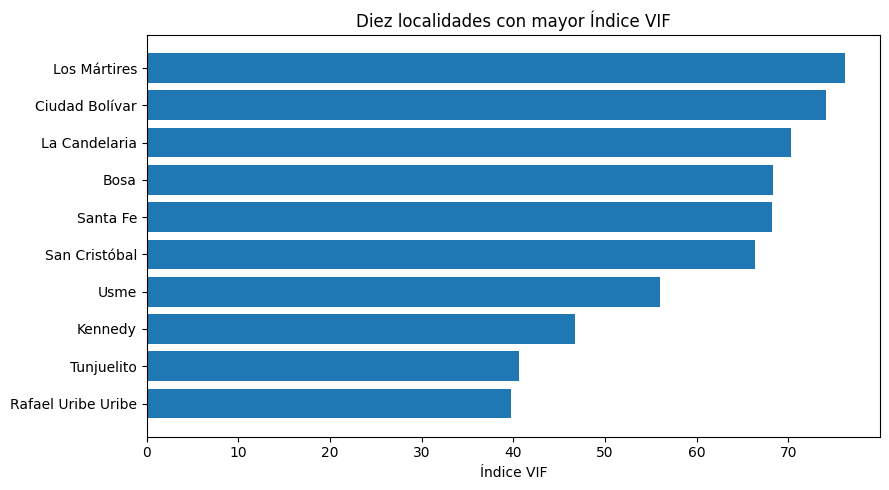

In [12]:
top = df.sort_values('indice_vif_familiar', ascending=False).head(10)

plt.figure(figsize=(9, 5))
plt.barh(top['localidad'][::-1], top['indice_vif_familiar'][::-1])
plt.xlabel('Índice VIF')
plt.title('Diez localidades con mayor Índice VIF')
plt.tight_layout()
plt.show()

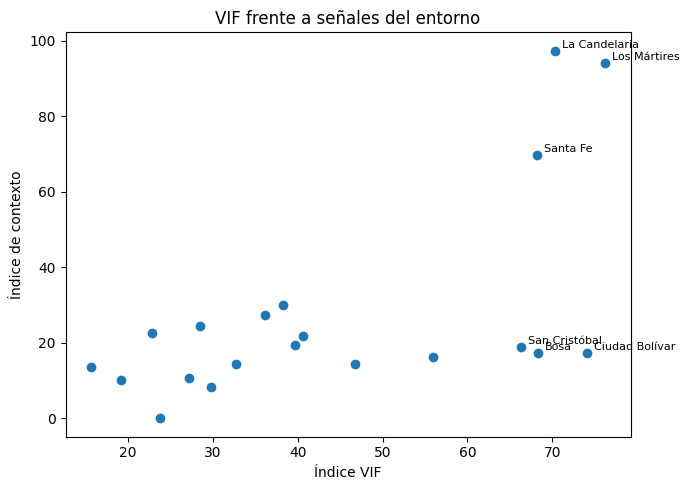

In [13]:
plt.figure(figsize=(7, 5))
plt.scatter(df['indice_vif_familiar'], df['indice_contexto'])
for _, row in df.iterrows():
    if row['indice_vif_familiar'] >= 60 or row['indice_contexto'] >= 60:
        plt.text(row['indice_vif_familiar'] + 0.8, row['indice_contexto'] + 0.8, row['localidad'], fontsize=8)
plt.xlabel('Índice VIF')
plt.ylabel('Índice de contexto')
plt.title('VIF frente a señales del entorno')
plt.tight_layout()
plt.show()

## 14. Base final para el visor

Se exporta una base integrada por localidad. Esta base es la que debe acompañar al visor en el repositorio para que la revisión técnica no dependa únicamente del HTML.


In [14]:
columnas_exportar = [
    'localidad', 'poblacion_ref',
    'vif_casos_2018_2025', 'vif_tasa_prom_anual_100k', 'vif_persistencia_anios', 'pct_mujeres_nna_vif',
    'lesiones_casos_2018_2025', 'lesiones_tasa_prom_anual_100k',
    'spa_abusivo_casos_2018_2025', 'spa_abusivo_tasa_prom_anual_100k',
    'indice_vif_familiar', 'indice_contexto', 'brecha_vif_contexto',
    'nivel_vif_familiar', 'nivel_contexto'
]

# Algunas columnas de texto pueden no estar en todas las versiones de la base.
columnas_exportar = [c for c in columnas_exportar if c in df.columns]
base_integrada = df[columnas_exportar].copy()

ruta_base_salida = OUTPUT_DIR / 'base_integrada_localidad_2018_2025.csv'
ruta_pruebas_salida = OUTPUT_DIR / 'resultados_pruebas_estadisticas.csv'
ruta_validaciones_salida = OUTPUT_DIR / 'validaciones_calidad.csv'

base_integrada.to_csv(ruta_base_salida, index=False, encoding='utf-8-sig')
resultados_estadisticos.to_csv(ruta_pruebas_salida, index=False, encoding='utf-8-sig')
validaciones_df.to_csv(ruta_validaciones_salida, index=False, encoding='utf-8-sig')

print('Archivos exportados:')
print('-', ruta_base_salida)
print('-', ruta_pruebas_salida)
print('-', ruta_validaciones_salida)

Archivos exportados:
- /mnt/data/outputs/base_integrada_localidad_2018_2025.csv
- /mnt/data/outputs/resultados_pruebas_estadisticas.csv
- /mnt/data/outputs/validaciones_calidad.csv


## 15. Control final

La entrega queda lista si todas las validaciones críticas están en `True`. Si alguna aparece en `False`, se debe revisar antes de publicar el visor.


In [15]:
validaciones_extra = []

validaciones_extra.append({
    'validacion': 'Diferencia máxima en tasa VIF',
    'valor': float((df['vif_tasa_prom_anual_100k'] - df['vif_tasa_recalculada']).abs().max()),
    'esperado': '<= 0.05',
    'ok': (df['vif_tasa_prom_anual_100k'] - df['vif_tasa_recalculada']).abs().max() <= 0.05
})

validaciones_extra.append({
    'validacion': 'Diferencia máxima en Índice VIF',
    'valor': float((df['indice_vif_familiar'] - df['indice_vif_recalculado']).abs().max()),
    'esperado': '<= 0.05',
    'ok': (df['indice_vif_familiar'] - df['indice_vif_recalculado']).abs().max() <= 0.05
})

validaciones_extra.append({
    'validacion': 'Diferencia máxima en índice de contexto',
    'valor': float((df['indice_contexto'] - df['indice_contexto_recalculado']).abs().max()),
    'esperado': '<= 0.05',
    'ok': (df['indice_contexto'] - df['indice_contexto_recalculado']).abs().max() <= 0.05
})

control_final = pd.concat([validaciones_df, pd.DataFrame(validaciones_extra)], ignore_index=True)
control_final

,validacion,valor,esperado,ok
0,Número de localidades,20.00,20,True
1,Filas por localidad,20.00,20,True
2,Localidades duplicadas,0.00,0,True
3,Casos VIF negativos,0.00,0,True
4,Persistencia máxima,8.00,<= 8,True
5,Total VIF,283773.00,283773,True
6,JSON sin claves duplicadas,0.00,0,True
7,Diferencia máxima en tasa VIF,0.00,<= 0.05,True
8,Diferencia máxima en Índice VIF,0.02,<= 0.05,True
9,Diferencia máxima en índice de contexto,0.00,<= 0.05,True


In [16]:
if control_final['ok'].all():
    print('Control final aprobado. La base, los indicadores y el visor son consistentes.')
else:
    print('Hay validaciones por revisar:')
    display(control_final[~control_final['ok']])

Control final aprobado. La base, los indicadores y el visor son consistentes.


## 16. Notas para el README

Texto sugerido para documentar el procesamiento:

> El procesamiento se realizó en Python a través de un notebook reproducible. Se consolidó una base por localidad para el periodo 2018-2025, se calcularon tasas promedio anuales por cada 100.000 habitantes, persistencia de VIF, Índice VIF, índice de contexto y brecha VIF-contexto. Las fuentes no se suman entre sí; se integran territorialmente mediante indicadores comparables. También se aplicaron pruebas estadísticas exploratorias de asociación territorial, sin interpretación causal.

Texto sugerido para documentar la visualización:

> El producto de visualización es un visor interactivo desarrollado en HTML, CSS y JavaScript. Permite consultar indicadores territoriales, gráficos, fichas por localidad y recomendaciones de política pública. El visor se entrega junto con el notebook, la base integrada y los archivos de validación.
